In [2]:
import torch
import sionna

print(torch.__version__)
print(sionna.__version__)

print("CUDA available: ", torch.cuda.is_available())

if torch.cuda.is_available( ):
    print("GPU device name:", torch.cuda.get_device_name())

2.13.0+cpu
2.0.1
CUDA available:  False


In [3]:
from sionna.phy.channel.tr38901 import UMa, PanelArray
carrier_frequency = 3.5e9  # 载波频率, 单位 Hz

ut_array = PanelArray(num_rows_per_panel=1, num_cols_per_panel=1,
                     polarization='single', polarization_type='V',
                     antenna_pattern='omni', carrier_frequency=carrier_frequency)  # 一个天线阵列

bs_array = PanelArray(num_rows_per_panel=1, num_cols_per_panel=4,
                      polarization='single', polarization_type='V',
                       antenna_pattern='38.901', carrier_frequency=carrier_frequency)
# 创建一个UMa信道模型
channel_model = UMa(
    carrier_frequency=carrier_frequency,
    o2i_model="low",
    ut_array=ut_array,
    bs_array=bs_array,
    direction="downlink",
    enable_pathloss=True,
    enable_shadow_fading=True,
)

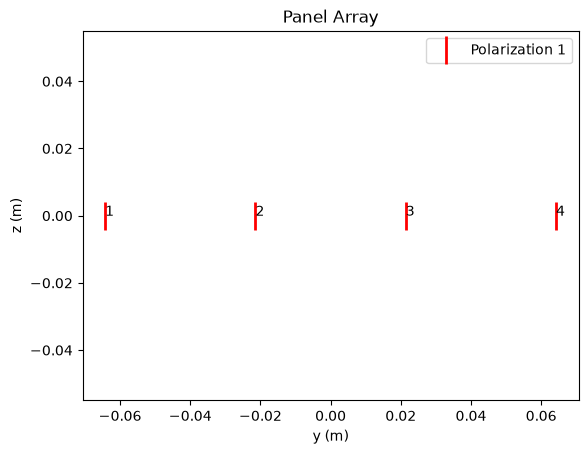

In [4]:
bs_array.show()

In [5]:
ut_loc = torch.tensor(
    [[[100.0, 0.0, 1.5]]],
    dtype=torch.float32,
)
bs_loc = torch.tensor(
    [[[0.0, 0.0, 25.0]]],
    dtype=torch.float32,
)
# bs_loc.shape
batch_size, num_ut, num_bs = 1, 1, 1
bs_orientation = torch.zeros(   # 设备的旋转姿态
    (batch_size, num_bs, 3),
    dtype=torch.float32,
)

ut_orientation = torch.zeros(
    (batch_size, num_ut, 3),
    dtype=torch.float32,
)

ut_velocities = torch.zeros(  # 设备的移动速度
    (batch_size, num_ut, 3),
    dtype=torch.float32,
)
in_state = torch.tensor( # 室内/室外状态
    [[False]],
    dtype=torch.bool,
)
los = False


In [6]:
channel_model.set_topology(
    ut_loc=ut_loc,
    bs_loc=bs_loc,
    ut_orientations=ut_orientation,
    bs_orientations=bs_orientation,
    ut_velocities=ut_velocities,
    in_state=in_state,
    los=False,
)

In [7]:
num_time_samples = 1
sampling_frequency = 1.0  # 采样频率 [Hz]，采样时间间隔 [s]=1/num_time_samples


# a: [batch size, num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_samples], `torch.complex`. Path coefficients.
#  tau: [batch size, num_rx, num_tx, num_paths], `torch.float`. Path delays [s].
a, tau = channel_model(
    num_time_samples=num_time_samples,
    sampling_frequency=sampling_frequency,
)

In [8]:
print("\n=== CIR information ===")

print("\na:")
print("type :", type(a))
print("dtype:", a.dtype)
print("shape:", a.shape)
# print("data:", a)

print("\ntau:")
print("type :", type(tau))
print("dtype:", tau.dtype)
print("shape:", tau.shape)
# print("data:", tau)




=== CIR information ===

a:
type : <class 'torch.Tensor'>
dtype: torch.complex64
shape: torch.Size([1, 1, 1, 1, 4, 24, 1])

tau:
type : <class 'torch.Tensor'>
dtype: torch.float32
shape: torch.Size([1, 1, 1, 24])


In [9]:
print("\nNumber of paths:")
print(a.shape[-2])


Number of paths:
24


In [10]:
a_link = a[
    0,  # batch
    0,  # UT
    0,  # UT antenna
    0,  # BS
    0,  # BS antenna
    :,  # all paths
    0,  # time sample
]

print("\nPath coefficients for BS antenna 0 -> UT antenna 0:")
print(a_link)


Path coefficients for BS antenna 0 -> UT antenna 0:
tensor([ 1.7153e-07+1.1098e-06j, -1.3503e-06-4.3118e-06j,
         2.7782e-06+1.1936e-06j, -3.7115e-06-1.2334e-06j,
         1.2720e-06+3.4086e-07j,  5.1517e-07+4.5471e-07j,
        -2.3691e-06+4.3068e-06j,  4.8469e-08+3.7375e-07j,
        -4.3508e-07+1.6792e-06j, -5.0421e-08+1.3071e-06j,
        -9.0324e-07-1.3284e-06j, -1.2227e-06+4.1283e-08j,
        -3.5067e-06-4.6386e-07j,  3.1028e-07+1.3566e-06j,
         2.8257e-06+8.6247e-07j, -7.0357e-07-5.9798e-07j,
         3.0400e-06-5.8258e-07j, -6.7648e-08+1.2251e-06j,
         1.8726e-08+1.7937e-07j,  1.6406e-06-1.2084e-06j,
        -6.3903e-07-5.2020e-07j, -6.1992e-07+1.3765e-07j,
        -4.0724e-07-4.2068e-07j,  1.4029e-07+1.5915e-06j])


In [11]:
amplitude = torch.abs(a_link)

print("\nPath amplitudes:")
print(amplitude)


Path amplitudes:
tensor([1.1229e-06, 4.5183e-06, 3.0237e-06, 3.9110e-06, 1.3168e-06, 6.8714e-07,
        4.9154e-06, 3.7688e-07, 1.7347e-06, 1.3081e-06, 1.6064e-06, 1.2234e-06,
        3.5373e-06, 1.3916e-06, 2.9544e-06, 9.2335e-07, 3.0953e-06, 1.2269e-06,
        1.8035e-07, 2.0376e-06, 8.2399e-07, 6.3501e-07, 5.8551e-07, 1.5977e-06])


In [12]:
tau_link = tau[0, 0, 0, :]
tau_ns = tau_link * 1e9

print("\nPath delay / amplitude")

for path_idx in range(len(tau_link)):
    print(
        f"path {path_idx:2d}: "
        f"delay = {tau_ns[path_idx].item():10.4f} ns, "
        f"|a| = {amplitude[path_idx].item():.6e}"
    )


Path delay / amplitude
path  0: delay =     0.0000 ns, |a| = 1.122947e-06
path  1: delay =   199.3403 ns, |a| = 4.518256e-06
path  2: delay =   204.3451 ns, |a| = 3.023742e-06
path  3: delay =   209.3498 ns, |a| = 3.911036e-06
path  4: delay =   355.8755 ns, |a| = 1.316843e-06
path  5: delay =   381.6660 ns, |a| = 6.871438e-07
path  6: delay =   387.0936 ns, |a| = 4.915393e-06
path  7: delay =   507.3083 ns, |a| = 3.768760e-07
path  8: delay =   590.1412 ns, |a| = 1.734653e-06
path  9: delay =   688.2421 ns, |a| = 1.308079e-06
path 10: delay =  1152.0527 ns, |a| = 1.606408e-06
path 11: delay =  1154.4451 ns, |a| = 1.223390e-06
path 12: delay =  1289.0449 ns, |a| = 3.537293e-06
path 13: delay =  1294.0497 ns, |a| = 1.391621e-06
path 14: delay =  1299.0543 ns, |a| = 2.954378e-06
path 15: delay =  1329.8589 ns, |a| = 9.233527e-07
path 16: delay =  1526.6222 ns, |a| = 3.095329e-06
path 17: delay =  1572.4999 ns, |a| = 1.226926e-06
path 18: delay =  1664.3345 ns, |a| = 1.803451e-07
path 19

In [13]:
from sionna.phy.channel import cir_to_ofdm_channel
from sionna.phy.channel import subcarrier_frequencies

In [14]:
fft_size = 64 # 可换成其他值
subcarrier_spacing = 30e3 
B=fft_size*subcarrier_spacing 
print("B:", B, "B/2:", B/2, "B/fft_size:", B/fft_size) # 总带宽 B=fft_size*subcarrier_spacing Hz
frequencies = subcarrier_frequencies(
    num_subcarriers=fft_size,
    subcarrier_spacing=subcarrier_spacing,
)
print("frequencies shape:", frequencies.shape)
print(frequencies)

B: 1920000.0 B/2: 960000.0 B/fft_size: 30000.0
frequencies shape: torch.Size([64])
tensor([-960000., -930000., -900000., -870000., -840000., -810000., -780000.,
        -750000., -720000., -690000., -660000., -630000., -600000., -570000.,
        -540000., -510000., -480000., -450000., -420000., -390000., -360000.,
        -330000., -300000., -270000., -240000., -210000., -180000., -150000.,
        -120000.,  -90000.,  -60000.,  -30000.,       0.,   30000.,   60000.,
          90000.,  120000.,  150000.,  180000.,  210000.,  240000.,  270000.,
         300000.,  330000.,  360000.,  390000.,  420000.,  450000.,  480000.,
         510000.,  540000.,  570000.,  600000.,  630000.,  660000.,  690000.,
         720000.,  750000.,  780000.,  810000.,  840000.,  870000.,  900000.,
         930000.])


In [15]:
# [batch size, num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, fft_size], 
# `torch.complex`.Channel frequency responses at ``frequencies``.

h_freq = cir_to_ofdm_channel(frequencies, a, tau, normalize=False)
print("\n=== Frequency-domain channel ===")
print("dtype:", h_freq.dtype)
print("shape:", h_freq.shape)

# a: [batch size, num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_samples], `torch.complex`. Path coefficients.
#  tau: [batch size, num_rx, num_tx, num_paths], `torch.float`. Path delays [s].
print("a shape:", a.shape)
print("tau shape:", tau.shape)


=== Frequency-domain channel ===
dtype: torch.complex64
shape: torch.Size([1, 1, 1, 1, 4, 1, 64])
a shape: torch.Size([1, 1, 1, 1, 4, 24, 1])
tau shape: torch.Size([1, 1, 1, 24])


In [16]:
h_link = h_freq[
    0,      # batch
    0,      # UT
    :,      # RX antennas
    0,      # BS
    :,      # TX antennas
    :,      # time
    :,      # subcarriers
]
h_link.shape

torch.Size([1, 4, 1, 64])

In [17]:
print("\nBS antenna 0 -> UT antenna 0")
print(h_link[0,0,0,:])


BS antenna 0 -> UT antenna 0
tensor([-3.5628e-06-1.5336e-05j, -6.1093e-06-1.3500e-05j,
        -7.9992e-06-1.1024e-05j, -9.0213e-06-8.1594e-06j,
        -9.0701e-06-5.2344e-06j, -8.1767e-06-2.6087e-06j,
        -6.5151e-06-6.1097e-07j, -4.3802e-06+5.2003e-07j,
        -2.1416e-06+6.8091e-07j, -1.8009e-07-7.5484e-08j,
         1.1788e-06-1.5488e-06j,  1.7215e-06-3.4281e-06j,
         1.3813e-06-5.3503e-06j,  2.4388e-07-6.9669e-06j,
        -1.4764e-06-8.0055e-06j, -3.4843e-06-8.3144e-06j,
        -5.4648e-06-7.8801e-06j, -7.1433e-06-6.8166e-06j,
        -8.3331e-06-5.3294e-06j, -8.9608e-06-3.6645e-06j,
        -9.0644e-06-2.0536e-06j, -8.7685e-06-6.6892e-07j,
        -8.2428e-06+4.0398e-07j, -7.6550e-06+1.1696e-06j,
        -7.1313e-06+1.7041e-06j, -6.7306e-06+2.1215e-06j,
        -6.4412e-06+2.5341e-06j, -6.1957e-06+3.0180e-06j,
        -5.9010e-06+3.5918e-06j, -5.4731e-06+4.2150e-06j,
        -4.8673e-06+4.8030e-06j, -4.0954e-06+5.2561e-06j,
        -3.2255e-06+5.4925e-06j, -2.3644e-

c:\Users\ASUS\.conda\envs\py313\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\ASUS\.conda\envs\py313\Lib\site-packages\matplotlib\cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


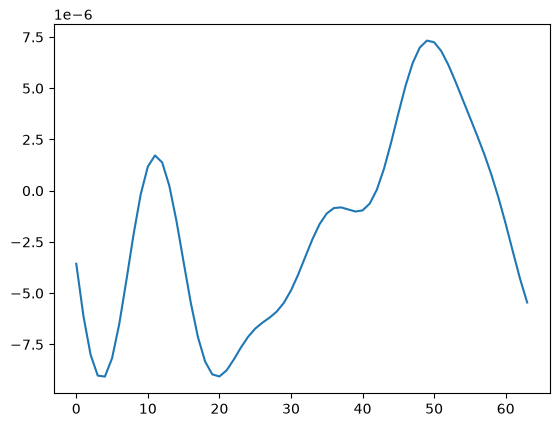

In [18]:
import matplotlib.pyplot as plt
plt.plot(h_link[0,0,0,:])

